✅ Configuration loaded.
Loaded columns: ['week_index', 'cases']
Using column 'cases' as case counts.
Detected last recorded point: 2026-W17
Series length: 538
Time series length: 538
Last recorded week: 2026-W17


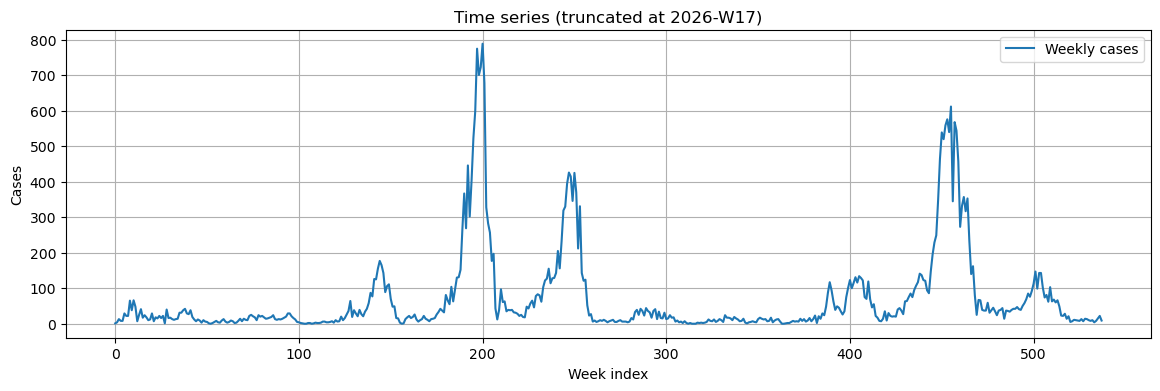

Training weeks: 417, Testing weeks: 121
Best RF params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}


In [ ]:
# %% [markdown]
# # 🔬 Forecasting from CSV (with smart truncation)
# 
# This notebook loads a weekly case time series from a CSV file,
# **truncates it at the last recorded week**, and provides a testing framework.
# 
# The CSV can be:
# - A single column with case counts (any name).
# - Columns `year`, `epi_week`, and a case column.
# - Or any combination where we can identify case data.

# %% [markdown]
# ## 1. Imports & Configuration

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION – EDIT THESE AS NEEDED
# ============================================================
CSV_PATH = "timeseries_truncated.csv"   # Change to your file
MIN_YEAR = 2016
MAX_YEAR = 2026
POPULATION = 2822255     # SLP population – adjust if needed
HORIZON = 2              # forecast horizon (weeks)
TRAIN_YEARS = ['2016','2017','2018','2019','2020','2021','2022','2023']
TEST_YEARS = ['2024','2025']   # use only complete years
# ============================================================

print("✅ Configuration loaded.")

# %% [markdown]
# ## 2. Load and Truncate CSV (smart detection)

# %%
def has_53_epi_weeks(year):
    jan1 = dt.date(year, 1, 1)
    dec31 = dt.date(year, 12, 31)
    if jan1.weekday() == 3 or dec31.weekday() == 3:
        return True
    is_leap = year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)
    if is_leap and jan1.weekday() == 2:
        return True
    return False

def load_and_truncate_csv(csv_path, min_year, max_year):
    df = pd.read_csv(csv_path)
    print(f"Loaded columns: {df.columns.tolist()}")

    # -----------------------------------------------------------------
    # 1. IDENTIFY THE CASE COLUMN
    # -----------------------------------------------------------------
    case_col = None
    # Try exact matches
    for col in ['cases', 'total_cases', 'Cases', 'Total_Cases']:
        if col in df.columns:
            case_col = col
            break
    # If not found, find any column with 'case' in it (case-insensitive)
    if case_col is None:
        for col in df.columns:
            if 'case' in col.lower():
                case_col = col
                break
    # If still not found, take the first numeric column (excluding 'year', 'epi_week', 'week_index')
    if case_col is None:
        for col in df.columns:
            if col.lower() not in ['year', 'epi_week', 'week_index', 'week', 'index']:
                if pd.api.types.is_numeric_dtype(df[col]):
                    case_col = col
                    break
    if case_col is None:
        raise ValueError("Could not identify a column with case counts.")

    print(f"Using column '{case_col}' as case counts.")

    # -----------------------------------------------------------------
    # 2. IF YEAR/EPI_WEEK ARE PRESENT, BUILD THE FULL SERIES
    # -----------------------------------------------------------------
    if 'year' in df.columns and 'epi_week' in df.columns:
        week_map = {(int(r.year), int(r.epi_week)): r[case_col] for _, r in df.iterrows()}
        last_year = df['year'].max()
        last_week = df[df['year'] == last_year]['epi_week'].max()
        print(f"Last recorded data point: {last_year}-W{last_week}")

        # Build full series up to max_year
        full_series = []
        for y in range(min_year, max_year + 1):
            max_w = 53 if has_53_epi_weeks(y) else 52
            for w in range(1, max_w + 1):
                full_series.append(week_map.get((y, w), 0))

        # Truncate
        idx = 0
        for y in range(min_year, last_year):
            idx += 53 if has_53_epi_weeks(y) else 52
        idx += last_week
        truncated_series = full_series[:idx]

        print(f"Full series length: {len(full_series)}")
        print(f"Truncated series length: {len(truncated_series)}")
        return truncated_series, last_year, last_week

    # -----------------------------------------------------------------
    # 3. OTHERWISE, ASSUME THE SERIES IS ALREADY CHRONOLOGICAL
    # -----------------------------------------------------------------
    # Get the series as a list
    series = df[case_col].tolist()
    # Determine the last year/week by counting weeks from min_year
    count = 0
    last_year = min_year
    last_week = 1
    for y in range(min_year, max_year + 1):
        max_w = 53 if has_53_epi_weeks(y) else 52
        for w in range(1, max_w + 1):
            count += 1
            if count == len(series):
                last_year = y
                last_week = w
                break
        if count == len(series):
            break
    if count != len(series):
        # If series length doesn't match full span, assume it's truncated.
        last_year = max_year
        last_week = 53 if has_53_epi_weeks(max_year) else 52
        print(f"Series length does not match full range. Assuming last year = {last_year}, week = {last_week}.")
    else:
        print(f"Detected last recorded point: {last_year}-W{last_week}")

    print(f"Series length: {len(series)}")
    return series, last_year, last_week

time_series, last_year, last_week = load_and_truncate_csv(CSV_PATH, MIN_YEAR, MAX_YEAR)

if len(time_series) == 0:
    raise ValueError("Time series is empty. Check your CSV file.")

print(f"Time series length: {len(time_series)}")
print(f"Last recorded week: {last_year}-W{last_week}")

# %% [markdown]
# ## 3. Visualise the (truncated) Time Series

# %%
plt.figure(figsize=(14, 4))
plt.plot(time_series, label='Weekly cases')
plt.xlabel('Week index')
plt.ylabel('Cases')
plt.title(f'Time series (truncated at {last_year}-W{last_week})')
plt.legend()
plt.grid(True)
plt.show()

# %% [markdown]
# ## 4. Forecasting Model Class (RF + GP)

# %%
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

class ForecastModel:
    def __init__(self, time_series, min_year, max_year, last_year, last_week,
                 horizon=2, population=2822255):
        self.time_series = time_series
        self.min_year = min_year
        self.max_year = max_year
        self.last_year = last_year
        self.last_week = last_week
        self.horizon = horizon
        self.population = population
        self.training_data = []
        self.testing_data = []

    def has_53_epi_weeks(self, year):
        return has_53_epi_weeks(year)

    def weeks_up_to(self, year, week=None):
        count = 0
        for y in range(self.min_year, year):
            count += 53 if self.has_53_epi_weeks(y) else 52
        if week is not None:
            count += week
        else:
            count += 53 if self.has_53_epi_weeks(year) else 52
        return count

    def create_training_testing_sets(self, years_train, years_test):
        last_train_year = max(int(y) for y in years_train)
        if last_train_year == self.last_year:
            train_end = self.weeks_up_to(last_train_year, self.last_week)
        else:
            train_end = self.weeks_up_to(last_train_year, None)

        self.training_data = self.time_series[:train_end]
        self.testing_data = self.time_series[train_end:]
        print(f"Training weeks: {len(self.training_data)}, Testing weeks: {len(self.testing_data)}")
        return self.training_data, self.testing_data

    def _prepare_xy(self, data, lag):
        X, Y = [], []
        for i in range(len(data) - lag - self.horizon - 1):
            X.append(data[i:i+lag])
            Y.append(data[i+lag:i+lag+self.horizon])
        return np.array(X), np.array(Y)

    def train_rf_gp(self, lag, rf_param_grid, gp_kernel_grid):
        X_train, Y_train = self._prepare_xy(self.training_data, lag)

        rf = RandomForestRegressor(random_state=42)
        grid_search = GridSearchCV(rf, rf_param_grid, cv=5,
                                   scoring='neg_mean_squared_error',
                                   n_jobs=-1, verbose=0)
        grid_search.fit(X_train, Y_train)
        best_rf = grid_search.best_estimator_
        print(f"Best RF params: {grid_search.best_params_}")

        Y_pred_rf = best_rf.predict(X_train).flatten()
        Y_train_flat = np.array(Y_train).flatten()
        residuals = Y_train_flat - Y_pred_rf
        X_train_repeated = np.repeat(X_train, self.horizon, axis=0)

        best_gp = None
        best_score = float('inf')
        for kernel in gp_kernel_grid:
            gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-2,
                                          normalize_y=True,
                                          n_restarts_optimizer=10,
                                          random_state=42)
            try:
                gp.fit(X_train_repeated, residuals)
                score = -gp.log_marginal_likelihood()
                if score < best_score:
                    best_score = score
                    best_gp = gp
            except Exception:
                continue
        if best_gp is None:
            raise RuntimeError("No GP kernel converged.")
        print(f"Best GP log-marginal likelihood: {best_score:.2f}")
        return best_rf, best_gp

    def evaluate(self, best_rf, best_gp, lag):
        X_test, Y_test = self._prepare_xy(self.testing_data, lag)
        if len(X_test) == 0:
            return None
        Y_pred_rf = best_rf.predict(X_test).flatten()
        X_test_repeated = np.repeat(X_test, self.horizon, axis=0)
        gp_res, gp_std = best_gp.predict(X_test_repeated, return_std=True)
        Y_pred = Y_pred_rf + gp_res
        Y_actual = np.array(Y_test).flatten()
        metrics = {
            'rmse': np.sqrt(mean_squared_error(Y_actual, Y_pred)),
            'mae': mean_absolute_error(Y_actual, Y_pred),
            'r2': r2_score(Y_actual, Y_pred)
        }
        return metrics, Y_actual, Y_pred, gp_std

    def predict_future(self, best_rf, best_gp, lag, num_weeks, last_known_series):
        series = last_known_series.copy()
        preds = []
        for _ in range(num_weeks):
            X_input = np.array(series[-lag:]).reshape(1, -1)
            Y_rf = best_rf.predict(X_input).flatten()
            X_repeated = np.repeat(X_input, self.horizon, axis=0)
            gp_res, _ = best_gp.predict(X_repeated, return_std=True)
            Y_pred = Y_rf + gp_res
            pred = Y_pred[0]
            preds.append(pred)
            series.append(pred)
        return preds

# %% [markdown]
# ## 5. Train and Evaluate RF+GP Model

# %%
rf_param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
gp_kernel_grid = [
    C(c, (1e-3, 1e3)) * RBF(l, (1e-4, 1e4)) + WhiteKernel(noise_level=n, noise_level_bounds=(1e-20, 1e+02))
    for c in [0.1, 0.5, 1.0, 2.0, 10.0, 100]
    for l in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
    for n in [1e-5, 1e-3]
]
LAG = 11

model = ForecastModel(time_series, MIN_YEAR, MAX_YEAR, last_year, last_week,
                      horizon=HORIZON, population=POPULATION)
model.create_training_testing_sets(TRAIN_YEARS, TEST_YEARS)

best_rf, best_gp = model.train_rf_gp(LAG, rf_param_grid, gp_kernel_grid)

metrics, y_actual, y_pred, y_std = model.evaluate(best_rf, best_gp, LAG)
print("\nTest Metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

plt.figure(figsize=(12, 4))
plt.plot(y_actual, label='Actual', marker='o')
plt.plot(y_pred, label='Predicted', marker='x')
plt.fill_between(range(len(y_actual)),
                 y_pred - 1.96*y_std,
                 y_pred + 1.96*y_std,
                 alpha=0.3, color='red')
plt.legend()
plt.title('RF+GP Forecast on Test Set')
plt.xlabel('Week index (test set)')
plt.ylabel('Cases')
plt.grid(True)
plt.show()

# %% [markdown]
# ## 6. Save the Trained Model (Optional)

# %%
# joblib.dump({'rf': best_rf, 'gp': best_gp}, 'my_rf_gp_model.joblib')

# %% [markdown]
# ## 7. Placeholder for Other Algorithms
# 
# Replace `train_rf_gp` with your own algorithm.  
# You have access to `self.training_data` and `self.testing_data` (lists of weekly counts).

# %%
print("✅ All done! Modify this notebook to test your own forecasting algorithms.")